3. Customer Churn Prediction: Develop a model to predict customer
churn in a subscription-based business.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
df = pd.read_csv("/content/drive/MyDrive/AIML_LAB/ep2,3,4_Reguesion/customer_churn_dataset.csv")
df.head()


,CustomerID,Gender,Age,Tenure_Months,SubscriptionType,MonthlyCharges,TotalCharges,PaymentMethod,SupportTickets,ContractType,Churn
0,CUST1000,Male,49,54,Standard,99.33,4912.77,Net Banking,1,Two Year,0
1,CUST1001,Female,56,8,Standard,12.01,604.59,Debit Card,2,Two Year,0
2,CUST1002,Male,66,27,Basic,57.62,2019.39,Cash,4,Two Year,0
3,CUST1003,Male,69,27,Premium,97.08,4848.88,Credit Card,7,Two Year,0
4,CUST1004,Male,49,34,Standard,54.69,4334.26,Credit Card,9,One Year,1


In [4]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        200 non-null    object 
 1   Gender            200 non-null    object 
 2   Age               200 non-null    int64  
 3   Tenure_Months     200 non-null    int64  
 4   SubscriptionType  200 non-null    object 
 5   MonthlyCharges    200 non-null    float64
 6   TotalCharges      200 non-null    float64
 7   PaymentMethod     200 non-null    object 
 8   SupportTickets    200 non-null    int64  
 9   ContractType      200 non-null    object 
 10  Churn             200 non-null    int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 17.3+ KB


,0
CustomerID,0
Gender,0
Age,0
Tenure_Months,0
SubscriptionType,0
MonthlyCharges,0
TotalCharges,0
PaymentMethod,0
SupportTickets,0
ContractType,0


In [5]:
df.fillna(method='ffill', inplace=True)


/tmp/ipykernel_238/4002983762.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [6]:
df['Churn'].value_counts()


,count
Churn,
0,143
1,57


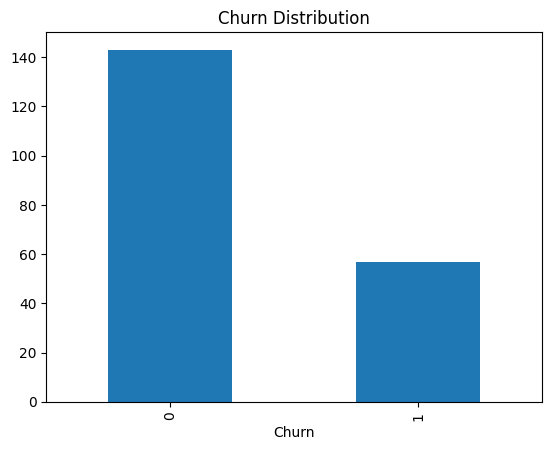

In [7]:
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.show()


In [8]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])


In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [12]:
y_pred = model.predict(X_test)


In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8


In [14]:
print(confusion_matrix(y_test, y_pred))


[[32  1]
 [ 7  0]]


In [15]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.82      0.97      0.89        33
           1       0.00      0.00      0.00         7

    accuracy                           0.80        40
   macro avg       0.41      0.48      0.44        40
weighted avg       0.68      0.80      0.73        40

